<a href="https://colab.research.google.com/github/shabnamsattar/Frank-Wolf-Algorithm-for-Recommender-Systems/blob/main/FW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_array
from scipy.sparse.linalg import svds

from sklearn.metrics import confusion_matrix, r2_score
from sklearn.model_selection import train_test_split

from time import time
from tqdm import tqdm, trange

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
class FrankWolfeRecommender:
    """
    This class includes all methods for:
     - Data processing
     - Model training (Frank-Wolfe with diminishing step-size and line search)
     - Evaluation and plotting
    """

    def __init__(self):

        pass

    def process_data(self, data, user_col, product_col, rating_col):

        unique_user_ids = np.sort(data[user_col].unique())
        user_mapping = {id_: num for num, id_ in enumerate(unique_user_ids)}

        unique_product_ids = np.sort(data[product_col].unique())
        product_mapping = {id_: num for num, id_ in enumerate(unique_product_ids)}

        # Map user IDs and product IDs to numeric values
        rows = data[user_col].map(user_mapping).values
        cols = data[product_col].map(product_mapping).values

        # Extract ratings
        unique_ratings = np.sort(data[rating_col].unique())
        ratings = data[rating_col].values

        return rows, cols, ratings, unique_user_ids, unique_product_ids, unique_ratings

    def process_predictions_dataset1(self, preds):
        """
        Clips and rounds predictions to the nearest integer within [1, 5].
        """
        return np.clip(np.round(preds), 1, 5)

    def process_predictions_dataset2(self, preds):
        """
        Clips and rounds predictions to the nearest 0.5 interval within [1, 5].
        """
        return np.clip(np.round(preds * 2) / 2, 1, 5)

    def create_random_matrix(self, m, n, delta):

        def normed_vec(length):
            vec = np.random.normal(size=length)
            return vec / np.linalg.norm(vec)

        def extreme_mat():
            r = normed_vec(m)
            c = normed_vec(n)
            return delta * np.outer(r, c)

        # Generate two extreme points.
        mat1 = extreme_mat()
        mat2 = extreme_mat()


        weight = np.random.random()


        return weight * mat1 + (1 - weight) * mat2

    def LMO(self, y, delta):

        u, sigma, vt = svds(-y, k=1, which='LM', solver='arpack')
        return delta * np.outer(u, vt)

    def _Gradient_(self, X, U):

        return 2 * (X - U)

    def _evaluation_train(self, X, U):

        r2_tr = r2_score(U, X)
        loss_tr = ((U - X) ** 2).sum()
        return r2_tr, loss_tr

    def _evaluation_test(self, X, U):

        r2_te = r2_score(U, X)
        loss_te = ((U - X) ** 2).sum()
        return r2_te, loss_te

    def fit(self,
            x_init,
            train_ratings, train_rows, train_cols,
            val_ratings, val_rows, val_cols,
            n_iter,
            delta):

        # Initialize metrics and variables
        train_losses_D = []
        train_r2_D = []
        test_losses_D = []
        test_r2_D = []
        acc_time_D = []
        dual_gap_D = []
        last_time = 0.0
        x_t = x_init.copy()
        m_shape = x_t.shape


        train_true_sparse = csr_array((train_ratings, (train_rows, train_cols)), shape=m_shape)

        print("Starting Frank-Wolfe algorithm (diminishing step-size)...\n")
        print(f"{'Epoch':<10}{'Train Loss':<25}{'Val Loss':<25}")

        for i in range(n_iter):
            t1 = time()
            alpha = 2 / (1 + i)  # diminishing step-size


            train_preds = x_t[train_rows, train_cols]
            test_preds = x_t[val_rows, val_cols]

            # Evaluate metrics
            r2_train, train_loss = self._evaluation_train(train_preds, train_ratings)
            r2_test, test_loss = self._evaluation_test(test_preds, val_ratings)


            train_preds_sparse = csr_array((train_preds, (train_rows, train_cols)), shape=m_shape)
            grad = self._Gradient_(train_preds_sparse, train_true_sparse)


            w_t = self.LMO(grad, delta)

            # Update x_t
            x_t_old = x_t
            x_t = x_t + alpha * (w_t - x_t)

            # Compute duality gap
            step_direction = w_t - x_t_old
            gap = (-grad).multiply(step_direction).sum()
            duality_gap = gap

            # Store metrics
            train_losses_D.append(train_loss)
            test_losses_D.append(test_loss)
            train_r2_D.append(r2_train)
            test_r2_D.append(r2_test)
            dual_gap_D.append(duality_gap)

            # Time tracking
            t2 = time()
            time_diff = (t2 - t1) * 1000.0
            acc_time_D.append(time_diff + last_time)
            last_time += time_diff


            print(f"{i:<10}{train_loss:<25.6f}{test_loss:<25.6f}")

        print("\nFrank-Wolfe algorithm (diminishing step-size) completed.")
        return x_t, train_losses_D, test_losses_D, train_r2_D, test_r2_D, acc_time_D, dual_gap_D

    def fit_line_search(self,
                        x_init,
                        train_ratings, train_rows, train_cols,
                        val_ratings, val_rows, val_cols,
                        n_iter,
                        delta):


        # Initialize metrics and variables
        train_losses_ls = []
        test_losses_ls = []
        train_r2_ls = []
        test_r2_ls = []
        acc_time_ls = []
        dual_gap_ls = []
        last_time = 0.0

        x_t = x_init.copy()
        m_shape = x_t.shape


        train_true_sparse = csr_array((train_ratings, (train_rows, train_cols)), shape=m_shape)

        print("Starting Frank-Wolfe algorithm (exact line search)...\n")
        print(f"{'Epoch':<10}{'Train Loss':<25}{'Val Loss':<25}")

        for i in range(n_iter):
            t1 = time()


            train_preds = x_t[train_rows, train_cols]
            test_preds = x_t[val_rows, val_cols]

            # Evaluate metrics
            r2_train, train_loss = self._evaluation_train(train_preds, train_ratings)
            r2_test, test_loss = self._evaluation_test(test_preds, val_ratings)


            train_preds_sparse = csr_array((train_preds, (train_rows, train_cols)), shape=m_shape)
            grad = self._Gradient_(train_preds_sparse, train_true_sparse)


            w_t = self.LMO(grad, delta)

            # EXACT line search
            A_data = train_preds - train_ratings
            B_data = w_t[train_rows, train_cols] - train_preds

            numerator = np.sum(A_data * B_data)
            denominator = np.sum(B_data * B_data)

            if denominator == 0.0:
                gamma = 0.0
            else:
                gamma = -numerator / denominator
                gamma = max(0.0, min(1.0, gamma))

            # Update x_t
            x_t_old = x_t
            x_t = x_t + gamma * (w_t - x_t)

            # Dual gap
            step_direction = w_t - x_t_old
            gap = (-grad).multiply(step_direction).sum()
            duality_gap = gap

            # Store metrics
            train_losses_ls.append(train_loss)
            test_losses_ls.append(test_loss)
            train_r2_ls.append(r2_train)
            test_r2_ls.append(r2_test)
            dual_gap_ls.append(duality_gap)

            # Time tracking
            t2 = time()
            time_diff = (t2 - t1) * 1000.0
            acc_time_ls.append(time_diff + last_time)
            last_time += time_diff


            print(f"{i:<10}{train_loss:<25.6f}{test_loss:<25.6f}")

        print("\nFrank-Wolfe algorithm (exact line search) completed.")
        return x_t, train_losses_ls, test_losses_ls, train_r2_ls, test_r2_ls, acc_time_ls, dual_gap_ls

    def compute_class_accuracy(self, true_labels, predicted_labels, unique_classes):

        cm = confusion_matrix(true_labels, predicted_labels, labels=unique_classes)
        accuracies = {
            cls: cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
            for i, cls in enumerate(unique_classes)
        }
        return cm, accuracies

    def plot_confusion_matrix(self, cm, unique_classes, title):

        df_cm = pd.DataFrame(cm, index=unique_classes, columns=unique_classes)
        plt.figure(figsize=(10, 7))
        sns.heatmap(df_cm, annot=True, fmt='d', cmap='viridis')
        plt.title(title)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

    def chart1(self, train_losses, test_losses, r2_train, r2_test, algorithm_):

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot losses
        axes[0].plot(train_losses, label='train')
        axes[0].plot(test_losses, label='test')
        axes[0].legend()
        axes[0].grid()
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(algorithm_)

        # Plot R^2
        axes[1].plot(r2_train, label='train')
        axes[1].plot(r2_test, label='test')
        axes[1].legend()
        axes[1].grid()
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('R2')
        axes[1].set_title(algorithm_)

        plt.show()

    def chart2(self, time_D, time_ls, dual_gap_D, dual_gap_ls, dataset_name):

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # 1) CPU time vs Iterations
        axes[0].plot(time_ls, label='Line Search')
        axes[0].plot(time_D, label='Diminishing step-size')
        axes[0].legend()
        axes[0].grid()
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('CPU time (ms)')
        axes[0].set_title(f'{dataset_name}: CPU time vs. Iterations')

        # 2) Duality Gap vs CPU Time
        axes[1].plot(time_ls, dual_gap_ls, label='Line Search')
        axes[1].plot(time_D, dual_gap_D, label='Diminishing step-size')
        axes[1].legend()
        axes[1].grid()
        axes[1].set_xlabel('CPU Time (ms)')
        axes[1].set_ylabel('Duality Gap')
        axes[1].set_title(f'{dataset_name}: Duality Gap vs. CPU Time')

        plt.show()


#Experiments

## Movielens Data

In [ ]:
path = kagglehub.dataset_download("prajitdatta/movielens-100k-dataset")
movielens = pd.read_csv(
    os.path.join(path, "ml-100k", "u.data"),
    sep="\t", header=None,
    names=['USER_ID', 'MOVIE_ID', 'RATE', 'TIMESTAMP'],
    usecols=[0,1,2],
    dtype={'USER_ID': str, 'MOVIE_ID': str, 'RATE': float}
)
print(movielens.head())


100%|██████████| 4.77M/4.77M [00:00<00:00, 67.4MB/s]

Extracting files...


  USER_ID MOVIE_ID  RATE
0     196      242   3.0
1     186      302   3.0
2      22      377   1.0
3     244       51   2.0
4     166      346   1.0


In [ ]:
data = movielens.dropna(subset=['RATE']).reset_index(drop=True)
print(data.shape)
print(data.head(10))

(100000, 3)
  USER_ID MOVIE_ID  RATE
0     196      242   3.0
1     186      302   3.0
2      22      377   1.0
3     244       51   2.0
4     166      346   1.0
5     298      474   4.0
6     115      265   2.0
7     253      465   5.0
8     305      451   3.0
9       6       86   3.0


Visualizing Class Distribution

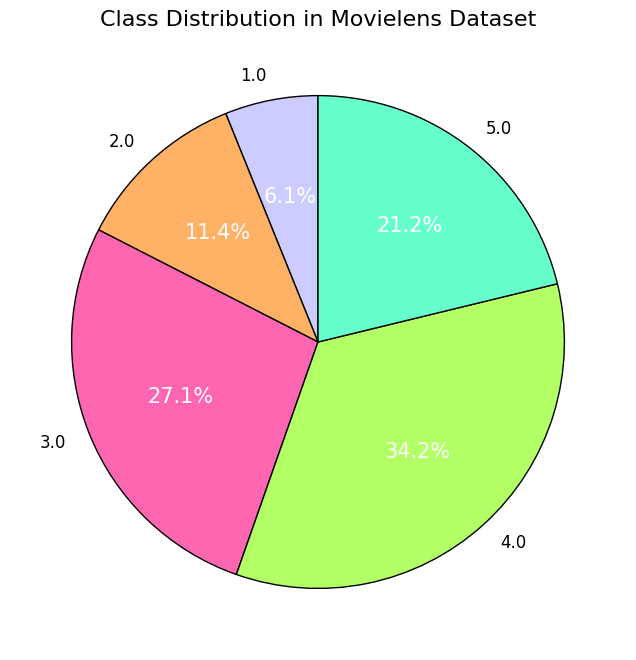

In [ ]:
unique_classes, counts = np.unique(data["RATE"], return_counts=True)
percentages = (counts / sum(counts)) * 100
custom_colors = ['#CCCCFF','#FFB266', '#FF66B2', '#B2FF66', '#66FFCC']


def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''


plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie (
    percentages,
    labels=unique_classes,
    autopct=autopct_format,
    startangle=90,
    colors=custom_colors,
    wedgeprops={'edgecolor': 'black'},
    labeldistance=1.1)

for text in texts:
    text.set_fontsize(12)
    text.set_color('black')

for autotext in autotexts:
    autotext.set_fontsize(15)
    autotext.set_color('white')

plt.title('Class Distribution in Movielens Dataset', fontsize=16)
plt.show()


In [ ]:
fw = FrankWolfeRecommender()


Process the data into row, col, and ratings arrays

In [ ]:
rows, cols, ratings, unique_users, unique_items, unique_ratings = fw.process_data(
    data,
    user_col='USER_ID',
    product_col='MOVIE_ID',
    rating_col='RATE'
)

Train-test split

In [ ]:
row_train, row_test, col_train, col_test, ratings_train, ratings_test = train_test_split(
    rows, cols, ratings, random_state=42
)

In [ ]:
delta = 5000
n_iter = 2000

Create initial matrix

In [ ]:
m_shape = (len(unique_users), len(unique_items))

x_init = fw.create_random_matrix(m_shape[0], m_shape[1], delta)

Frank-Wolfe with diminishing step-size

In [ ]:
preds_D, train_losses_D, test_losses_D, r2_train_D, r2_test_D, time_D, dual_gap_D = fw.fit(
    x_init,
    ratings_train, row_train, col_train,
    ratings_test, row_test, col_test,
    n_iter, delta
)

Starting Frank-Wolfe algorithm (diminishing step-size)...

Epoch     Train Loss               Val Loss                 
0         2115468.799049           711740.646171            
1         39609967.122301          12344946.547648          
2         17550231.387492          5196464.770709           
3         2532558.247454           694817.673178            
4         3400924.639662           797069.045944            
5         1504425.126821           348374.174787            
6         1999091.218870           351732.437845            
7         1232195.049094           294913.567930            
8         1503731.352090           305069.623669            
9         1099301.598730           297289.122682            
10        1268592.440989           303583.340846            
11        1005256.781239           295546.951613            
12        540817.760470            162327.505426            
13        694855.291638            164542.929611            
14        600991.314118   

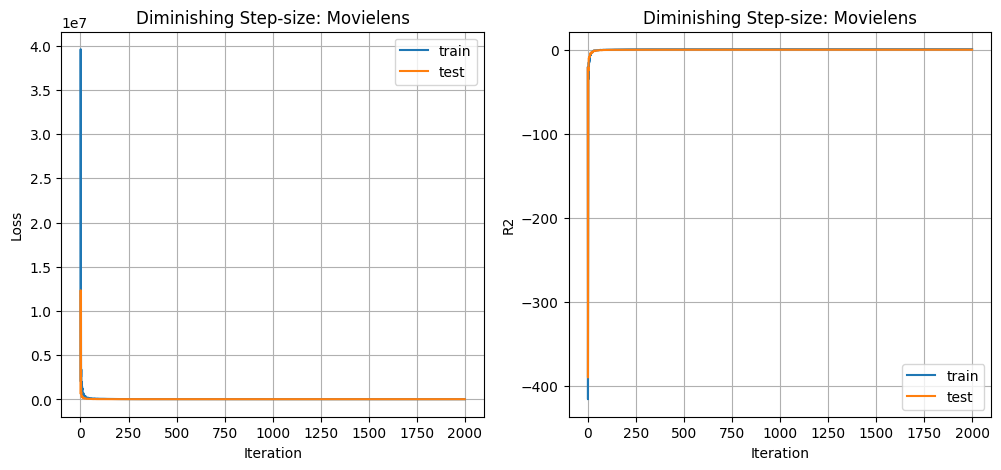

In [ ]:
fw.chart1(train_losses_D, test_losses_D, r2_train_D, r2_test_D,
          "Diminishing Step-size: Movielens")

Convert predictions to integer-based ratings [1:5]

In [ ]:
processed_preds_D = fw.process_predictions_dataset1(preds_D)
train_prosessed_preds_D = processed_preds_D [row_train, col_train]
test_prosessed_preds_D = processed_preds_D [row_test, col_test]


Compute confusion matrix and accuracy

In [ ]:
cm_train_D, train_accuracies_D = fw.compute_class_accuracy(ratings_train, train_prosessed_preds_D, unique_ratings)
cm_test_D, test_accuracies_D = fw.compute_class_accuracy(ratings_test, test_prosessed_preds_D, unique_ratings)

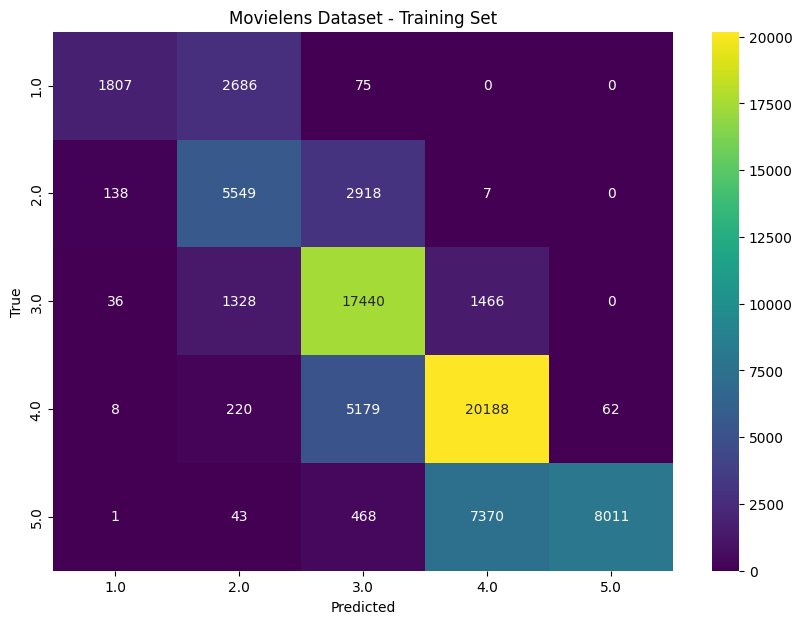

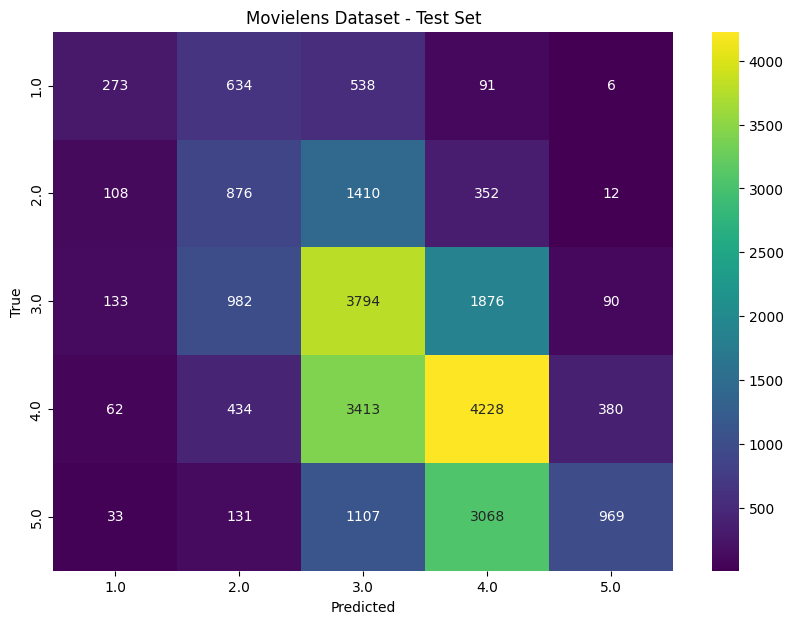

In [ ]:
# Plot confusion matrices
fw.plot_confusion_matrix(cm_train_D, unique_ratings, "Movielens Dataset - Training Set")
print("")
fw.plot_confusion_matrix(cm_test_D, unique_ratings, "Movielens Dataset - Test Set")

In [ ]:
# Print accuracies
print("Training Set Accuracies per Class:", train_accuracies_D)
print("Test Set Accuracies per Class:", test_accuracies_D)

Training Set Accuracies per Class: {1.0: 0.39557793345008757, 2.0: 0.6443334881560613, 3.0: 0.8603848051307351, 4.0: 0.7868417975601201, 5.0: 0.5040583904863777}
Test Set Accuracies per Class: {1.0: 0.17704280155642024, 2.0: 0.31762146482958664, 3.0: 0.5518545454545455, 4.0: 0.496418926852178, 5.0: 0.18255463451394122}


Frank-Wolfe with Exact Line Seach

In [ ]:
preds_ls, train_losses_ls, test_losses_ls, \
    r2_train_ls, r2_test_ls, time_ls, dual_gap_ls = fw.fit_line_search (x_init, ratings_train,
                                           row_train, col_train,
                                           ratings_test, row_test,
                                           col_test, n_iter, delta)

Starting Frank-Wolfe algorithm (exact line search)...

Epoch     Train Loss               Val Loss                 
0         2115468.799049           711740.646171            
1         1150740.010876           391026.753645            
2         623966.262826            211823.047357            
3         525098.516413            183719.717446            
4         475799.890591            166956.858484            
5         306704.754356            109953.929205            
6         266168.205997            96448.635968             
7         217478.294547            79615.322097             
8         204973.804087            75675.213828             
9         181482.197784            67514.421217             
10        171875.219602            64877.023817             
11        159339.345010            60437.455297             
12        155051.675489            59648.915759             
13        145810.964999            56608.876546             
14        138314.628220       

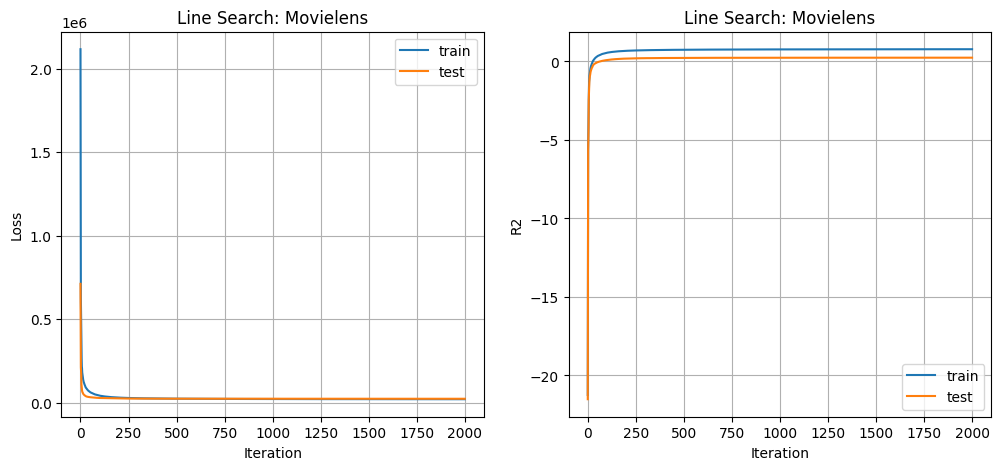

In [ ]:
fw.chart1 (train_losses_ls, test_losses_ls, r2_train_ls,
                  r2_test_ls,'Line Search: Movielens')

Convert predictions to integer-based ratings [1:5]

In [ ]:
prosessed_preds_ls = fw.process_predictions_dataset1(preds_ls)
train_prosessed_preds_ls = prosessed_preds_ls[row_train, col_train]
test_prosessed_preds_ls = prosessed_preds_ls[row_test, col_test]

Compute confusion matrix and accuracy

In [ ]:
cm_train_ls, train_accuracies_ls = fw.compute_class_accuracy(ratings_train, train_prosessed_preds_ls, unique_ratings)
cm_test_ls, test_accuracies_ls = fw.compute_class_accuracy(ratings_test, test_prosessed_preds_ls, unique_ratings)

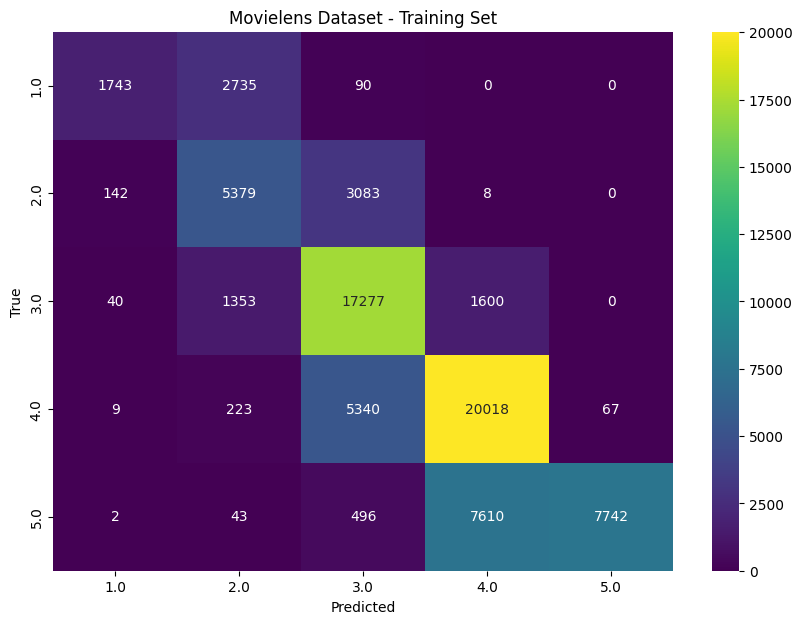

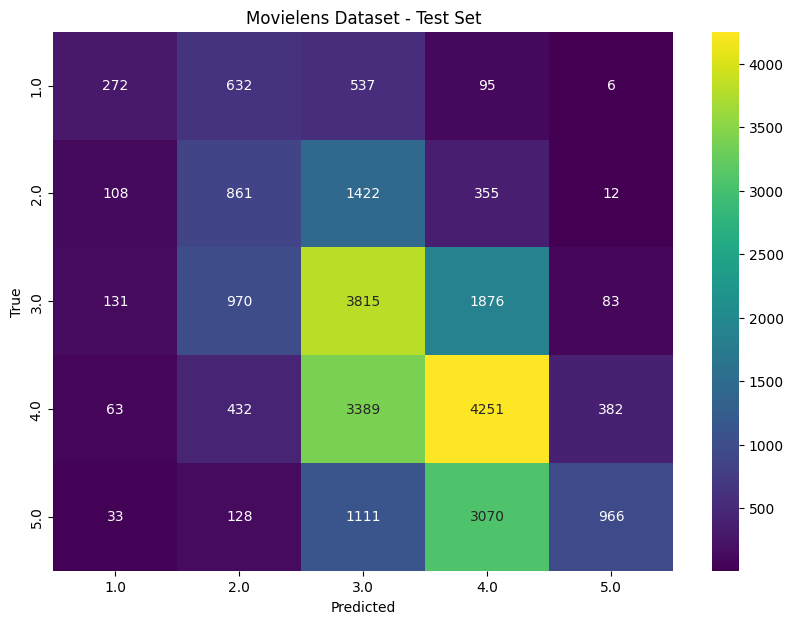

In [ ]:
fw.plot_confusion_matrix(cm_train_ls, unique_ratings, "Movielens Dataset - Training Set")
fw.plot_confusion_matrix(cm_test_ls, unique_ratings, "Movielens Dataset - Test Set")


Accuracies

In [ ]:
print("Training Set Accuracies per Class:", train_accuracies_ls)
print("Test Set Accuracies per Class:", test_accuracies_ls)

Training Set Accuracies per Class: {1.0: 0.3815674255691769, 2.0: 0.6245935903390618, 3.0: 0.8523433645781944, 4.0: 0.7802159254784269, 5.0: 0.4871326999307871}
Test Set Accuracies per Class: {1.0: 0.17639429312581065, 2.0: 0.31218274111675126, 3.0: 0.5549090909090909, 4.0: 0.49911940824233886, 5.0: 0.18198944988696308}


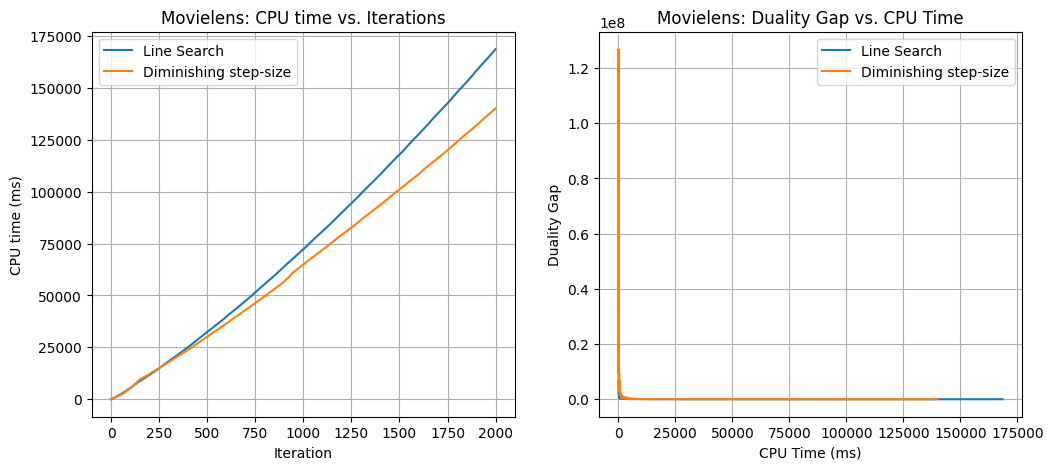

In [ ]:
fw.chart2 (time_D, time_ls, dual_gap_D, dual_gap_ls, "Movielens")

## X-Wines Data

In [ ]:
path = kagglehub.dataset_download("rogerioxavier/x-wines-slim-version")
df = pd.read_csv(
    os.path.join(path, "XWines_Slim_150K_ratings.csv"),
    usecols=[1, 2, 4],
    dtype={'UserID': str, 'WineID ': str, 'Rating': float}
)
print(df.head())
print(df.shape)


100%|██████████| 41.8M/41.8M [00:00<00:00, 56.6MB/s]

Extracting files...


    UserID  WineID  Rating
0  1356810  103471     4.5
1  1173759  111415     5.0
2  1164877  111395     5.0
3  1207665  111433     5.0
4  1075841  111431     5.0
(150000, 3)


In [ ]:
data = df.dropna(subset=['Rating']).reset_index(drop=True)
print(data.shape)

(150000, 3)


Visualizing Class Distribution

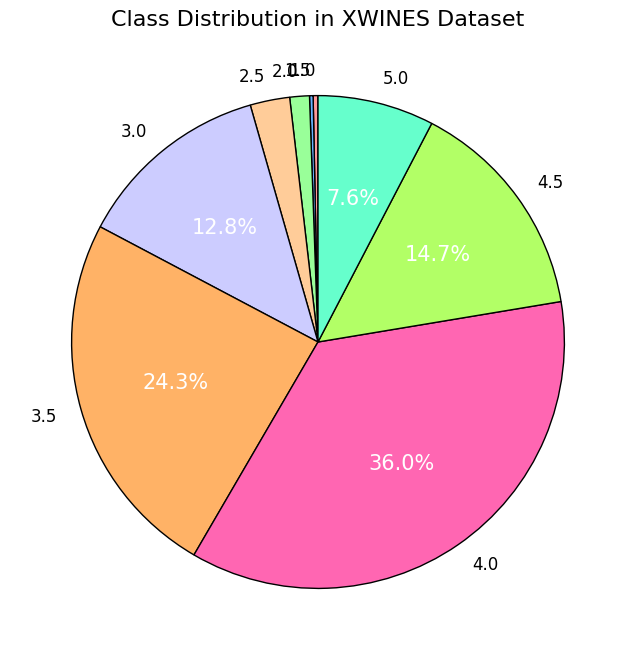

In [ ]:
unique_classes, counts = np.unique(data["Rating"], return_counts=True)
percentages = (counts / sum(counts)) * 100
custom_colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#CCCCFF',
                 '#FFB266', '#FF66B2', '#B2FF66', '#66FFCC']


def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 7 else ''


plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    percentages,
    labels=unique_classes,
    autopct=autopct_format,
    startangle=90,
    colors=custom_colors,
    wedgeprops={'edgecolor': 'black'},
    labeldistance=1.1)


for text in texts:
    text.set_fontsize(12)
    text.set_color('black')

for autotext in autotexts:
    autotext.set_fontsize(15)
    autotext.set_color('white')


plt.title('Class Distribution in XWINES Dataset', fontsize=16)
plt.show()


Process the data into row, col, and ratings arrays

In [ ]:
rows, cols, ratings, unique_user_ids, unique_product_ids, unique_ratings = fw.process_data (data, 'UserID', 'WineID', 'Rating')

Train and test split

In [ ]:
row_train, row_test, col_train, col_test, \
    ratings_train, ratings_test = train_test_split(rows, cols,
                                                   ratings,
                                                   random_state=42)

In [ ]:
delta = 10000
n_iter = 2000

Create initial matrix

In [ ]:
m_shape = (len(unique_user_ids), len(unique_product_ids))
x_init = fw.create_random_matrix(m_shape[0], m_shape[1], delta)

Frank-Wolfe with diminishing step-size

In [ ]:
preds_D, train_losses_D, test_losses_D, \
    r2_train_D, r2_test_D, time_D, dual_gap_D  =  fw.fit (x_init, ratings_train,
                                           row_train, col_train,
                                           ratings_test, row_test,
                                           col_test, n_iter,
                                            delta )

Starting Frank-Wolfe algorithm (diminishing step-size)...

Epoch     Train Loss               Val Loss                 
0         2305084.336293           764334.350525            
1         32957342.484120          7646339.651334           
2         40746497.392548          5938875.400169           
3         13722932.355798          1097319.622675           
4         12196381.083639          635246.250482            
5         5810213.713755           582254.430771            
6         5733177.955730           573274.143099            
7         3637417.736167           566934.259638            
8         3824602.572159           564365.052092            
9         2792313.234485           561971.899001            
10        3010199.234377           560931.243058            
11        2379611.981477           559566.713019            
12        2586372.857482           559141.656076            
13        2148267.391911           558123.432466            
14        2336472.365092  

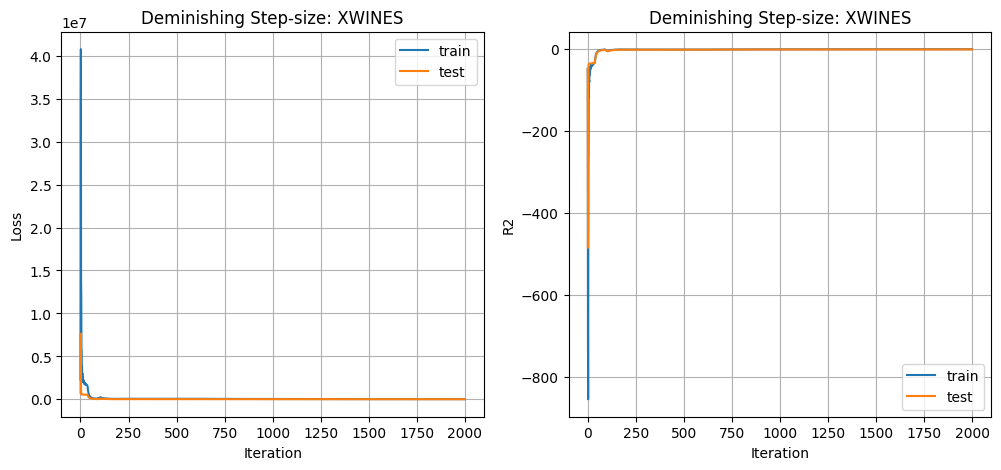

In [ ]:
fw.chart1(train_losses_D, test_losses_D, r2_train_D,
                  r2_test_D,'Deminishing Step-size: XWINES')


Convert predictions to integer-based ratings [1:5]

In [ ]:
prosessed_preds_D = fw.process_predictions_dataset2(preds_D)
train_prosessed_preds_D = prosessed_preds_D[row_train, col_train]
test_prosessed_preds_D = prosessed_preds_D[row_test, col_test]

Compute confusion matrix and accuracy

In [ ]:
ratings_train = ratings_train.astype(str)
train_prosessed_preds_D = train_prosessed_preds_D.astype(str)

ratings_test = ratings_test.astype(str)
test_prosessed_preds_D = test_prosessed_preds_D.astype(str)

unique_ratings = [str(x) for x in unique_ratings]

cm_train_D, train_accuracies_D = fw.compute_class_accuracy(ratings_train, train_prosessed_preds_D, unique_ratings)
cm_test_D, test_accuracies_D = fw.compute_class_accuracy(ratings_test, test_prosessed_preds_D, unique_ratings)


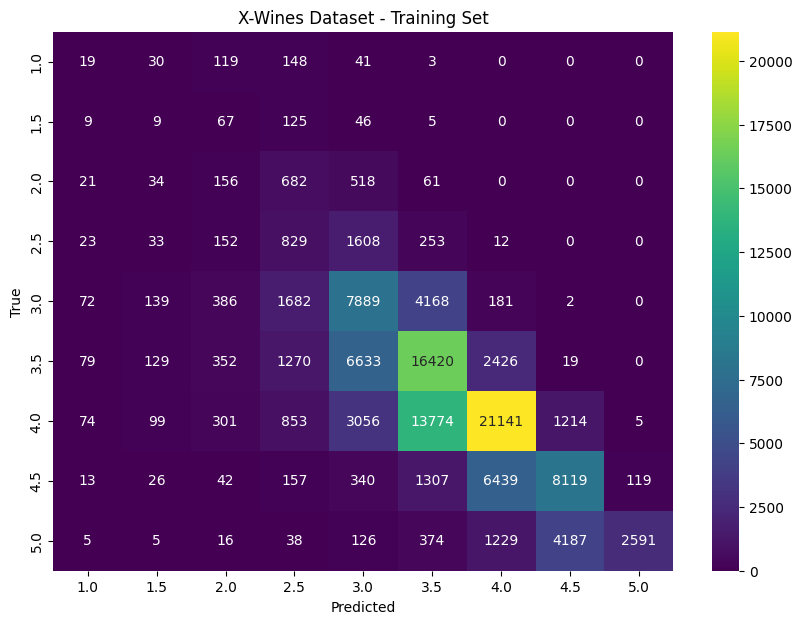

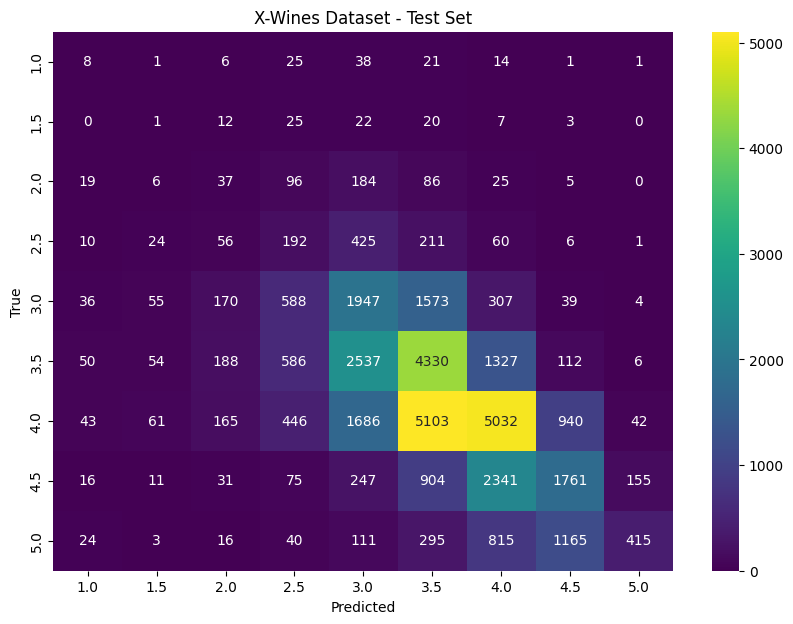

In [ ]:
fw.plot_confusion_matrix(cm_train_D, unique_ratings, "X-Wines Dataset - Training Set")
fw.plot_confusion_matrix(cm_test_D, unique_ratings, "X-Wines Dataset - Test Set")

In [ ]:
print("Training Set Accuracies per Class:", train_accuracies_D)
print("Test Set Accuracies per Class:", test_accuracies_D)

Training Set Accuracies per Class: {'1.0': 0.05277777777777778, '1.5': 0.034482758620689655, '2.0': 0.10597826086956522, '2.5': 0.28487972508591064, '3.0': 0.5433569805082995, '3.5': 0.6008489461358314, '4.0': 0.5217809808228645, '4.5': 0.49021857263615504, '5.0': 0.30229844825574614}
Test Set Accuracies per Class: {'1.0': 0.06956521739130435, '1.5': 0.011111111111111112, '2.0': 0.08078602620087336, '2.5': 0.1949238578680203, '3.0': 0.4125874125874126, '3.5': 0.47116430903155604, '4.0': 0.3722444148542684, '4.5': 0.31781266919328643, '5.0': 0.14389736477115117}


In [ ]:
delta = 12500
n_iter = 2000

In [ ]:
m_shape = (len(unique_user_ids), len(unique_product_ids))
x_init = fw.create_random_matrix(m_shape[0], m_shape[1], delta)

In [ ]:
preds_ls, train_losses_ls, test_losses_ls, \
    r2_train_ls, r2_test_ls, time_ls, dual_gap_ls = fw.fit_line_search (x_init, ratings_train,
                                           row_train, col_train,
                                           ratings_test, row_test,
                                           col_test, n_iter,
                                            delta)

Starting Frank-Wolfe algorithm (exact line search)...

Epoch     Train Loss               Val Loss                 
0         2568701.075353           858132.960902            
1         1331535.956608           465172.098938            
2         1188036.047552           432803.473717            
3         1109818.221355           407120.610311            
4         1085175.352662           404590.079150            
5         721427.734159            288231.786381            
6         679920.964775            285954.651225            
7         567809.918158            239885.584292            
8         545387.442100            236460.276988            
9         495110.259302            216871.945574            
10        477621.549291            211575.951197            
11        381695.199651            164325.299021            
12        359650.987191            164351.620154            
13        342388.820453            158717.533367            
14        339085.911411       

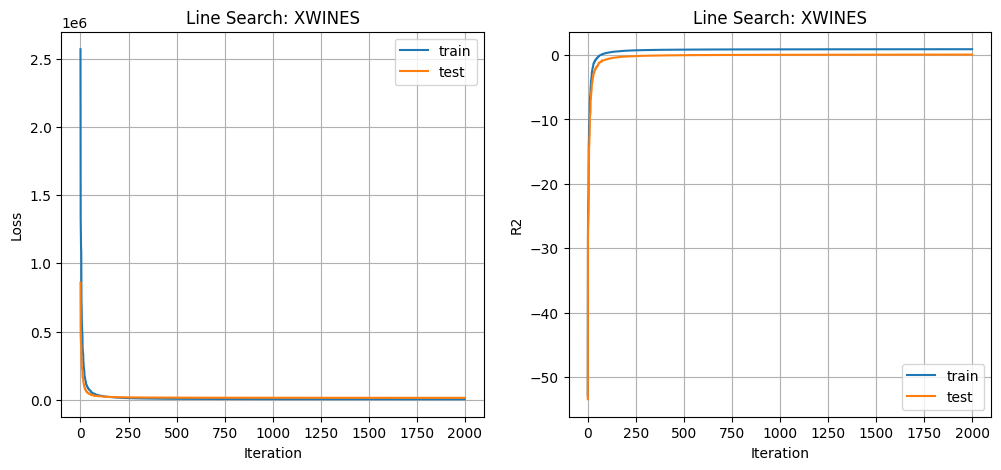

In [ ]:
fw.chart1 (train_losses_ls, test_losses_ls, r2_train_ls,
                  r2_test_ls, 'Line Search: XWINES')


Convert predictions to integer-based ratings [1:5]

In [ ]:
prosessed_preds_ls = fw.process_predictions_dataset2(preds_ls)
train_prosessed_preds_ls = prosessed_preds_ls[row_train, col_train]
test_prosessed_preds_ls = prosessed_preds_ls[row_test, col_test]


Compute confusion matrix and accuracy

In [ ]:
ratings_train = ratings_train.astype(str)
train_prosessed_preds_ls = train_prosessed_preds_ls.astype(str)

ratings_test = ratings_test.astype(str)
test_prosessed_preds_ls = test_prosessed_preds_ls.astype(str)

unique_ratings = [str(x) for x in unique_ratings]

cm_train_ls, train_accuracies_ls = fw.compute_class_accuracy(ratings_train, train_prosessed_preds_ls, unique_ratings)
cm_test_ls, test_accuracies_ls = fw.compute_class_accuracy(ratings_test, test_prosessed_preds_ls, unique_ratings)


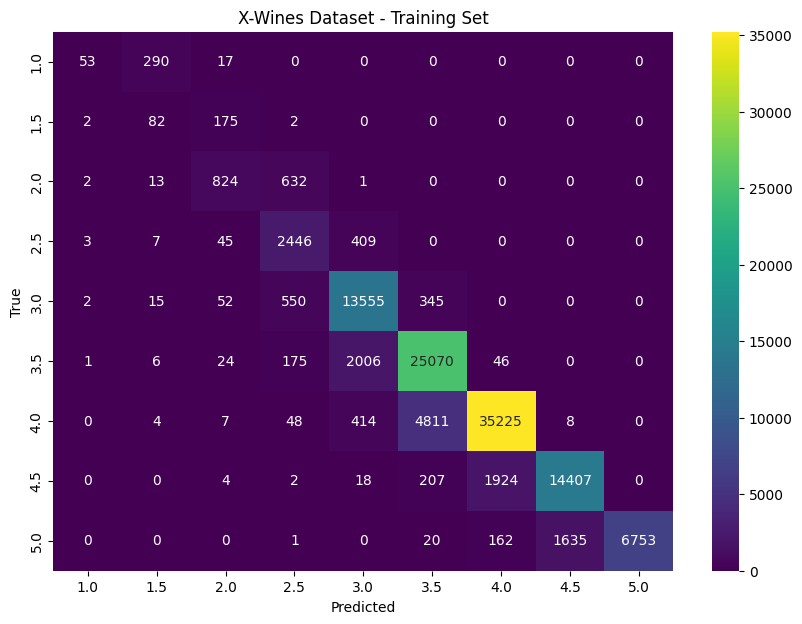

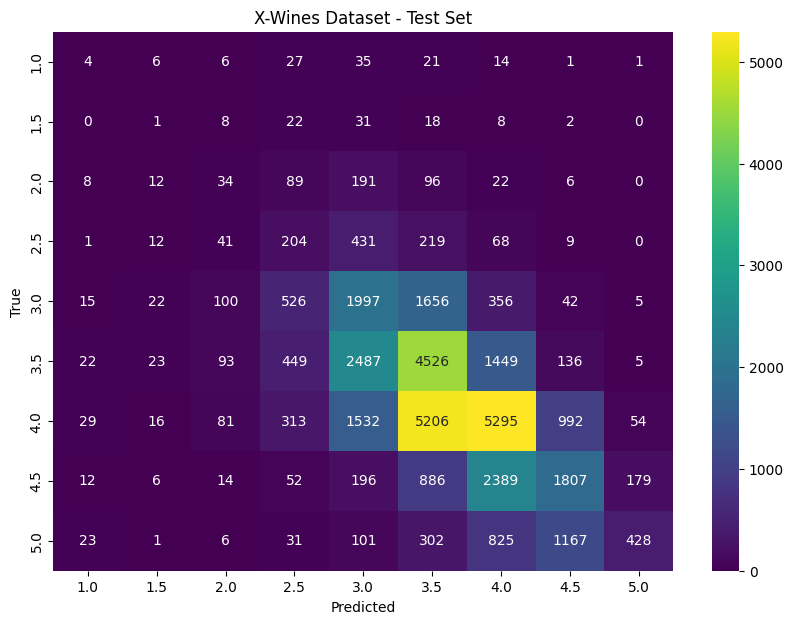

In [ ]:
fw.plot_confusion_matrix(cm_train_ls, unique_ratings, "X-Wines Dataset - Training Set")
print("")
fw.plot_confusion_matrix(cm_test_ls, unique_ratings, "X-Wines Dataset - Test Set")


In [ ]:
print("Training Set Accuracies per Class:", train_accuracies_ls)
print("Test Set Accuracies per Class:", test_accuracies_ls)

Training Set Accuracies per Class: {'1.0': 0.14722222222222223, '1.5': 0.31417624521072796, '2.0': 0.5597826086956522, '2.5': 0.8405498281786942, '3.0': 0.9336042427164405, '3.5': 0.9173741217798594, '4.0': 0.8693881580571118, '4.5': 0.8698828643883589, '5.0': 0.7878893944697235}
Test Set Accuracies per Class: {'1.0': 0.034782608695652174, '1.5': 0.011111111111111112, '2.0': 0.07423580786026202, '2.5': 0.20710659898477157, '3.0': 0.4231828777283323, '3.5': 0.4924918389553863, '4.0': 0.3916999556147359, '4.5': 0.32611441977982314, '5.0': 0.14840499306518723}


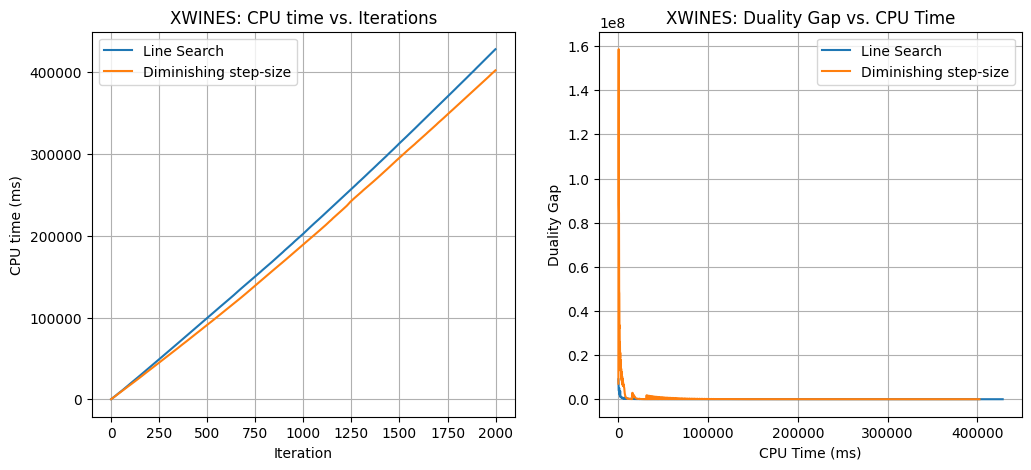

In [ ]:
fw.chart2 (time_D, time_ls, dual_gap_D, dual_gap_ls, "XWINES")